In [2]:
# Here is the installation process 
# First we create a virtual python environment using terminal on Mac on Command Prompt
"""
   python3 -m venv name_of_your_virtual_enviroment
   source bin/activate
   pip install qiskit
   pip install qiskit_aer
"""
# Once this installation is complete, you can start writing your programs either using Jupyter notebooks or open a empty file using vim in terminal
""" 
    vi demo.py
"""
# Add this line to the top of the file
""" 
   #!/usr/bin/env python
"""
# For jupyter notebook 
"""
   pip install notebook
"""
# Launch it using jupyter notebook from terminal -- a new tab opens up in your browser

# Now let's build a simple program for sampling a Quantum Circuit 
# We need to import Qiskit primitives to build the circuit



import matplotlib
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendSamplerV2 as Sampler


# Plotting function
def plot_final_distribution(final_distribution_bin): 

    matplotlib.rcParams.update({"font.size": 10})
    final_bits = final_distribution_bin
    
    fig = plt.figure(figsize=(11, 6))
    ax = fig.add_subplot(1, 1, 1)
    plt.xticks(rotation=45)
    plt.title("Result Distribution")
    plt.xlabel("Bitstrings (reversed)")
    plt.ylabel("Probability")
    ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:purple")
    plt.show()



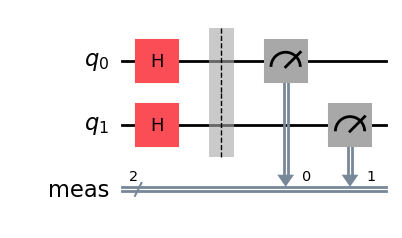

In [3]:
num_qubits = 2
clbits = 2 # of classical bits
# define a circuit
circuit = QuantumCircuit(num_qubits, clbits) # the initial state for each qubit is the state |0>
for i in range(2):
    circuit.h(i) # apply Hadamard operation H = [[1,1],[1,-1]]/sqrt(2) to each qubut
    
circuit.measure_all() # measure each qubit in the computational basis
circuit.draw("mpl", fold=False, idle_wires=False) 



counts_int:{0: 271, 3: 253, 1: 243, 2: 233}


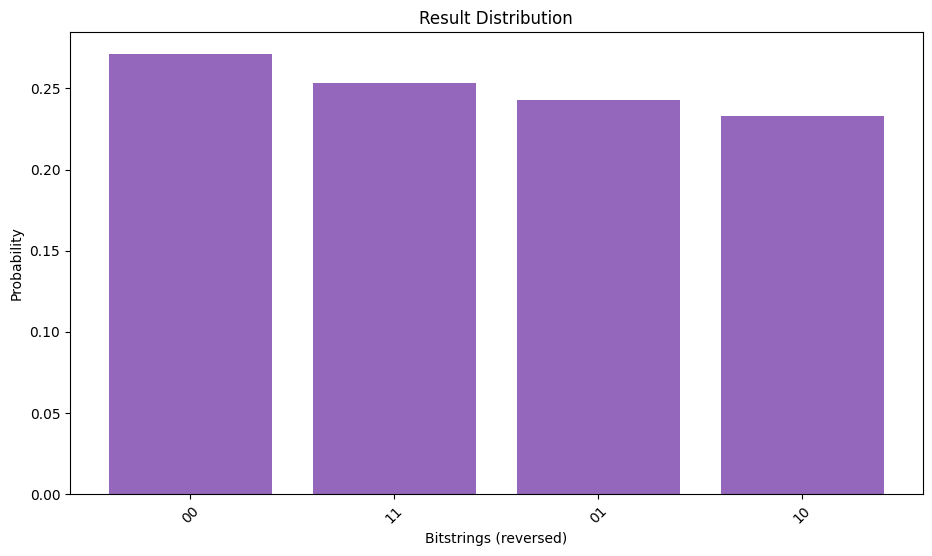

In [4]:
# create a primitive unit bloc -- a tuple of objecct e.g (circuit, hamiltonian, parameters)
# we don't need a hamiltonian or parameters for now
pub = (circuit,) 
# Instantiate a backend
backend = AerSimulator()
# Instantiate circuit sampler with backend
sampler = Sampler(backend= backend)
# set shots or number of samples 
sampler.options.default_shots = 1000
job = sampler.run([pub], shots=int(1e3))
# counts for basis states
counts_int = job.result()[0].data.meas.get_int_counts()
print(f"counts_int:{counts_int}") # prints counts for basis state represented as integers

counts_bin = job.result()[0].data.meas.get_counts()

shots = sum(counts_int.values())

final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}#

plot_final_distribution(final_distribution_bin)

Another important state is the GHZ state
$$\ket{\psi} = \frac{1}{\sqrt{2}}(\ket{000}+\ket{111})$$
We need the two qubit gate called the CNOT gate to build this state
$$ CNOT = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\0 & 0 & 1 & 0 \end{pmatrix} $$
Another way to represent the CNOT operation(gate) is through projective operators
$$CNOT = P_{0}\otimes I + P_{1} \otimes X $$
where
$$ P_{0} = \ket{0}\bra{0} \hspace{0.5cm} P_{1} = \ket{1}\bra{1} $$
Using the Hadamard and CNOT gates we can build the GHZ state. Write a 3-qubit circuit to build the GHZ state

In [ ]:
num_qubits = 3
clbits = 3 # of classical bits
# define a circuit
circuit = QuantumCircuit(num_qubits, clbits) # the initial state for each qubit is the state |0>
# apply hadamard to the first qubit
circuit.h(0)
# apply CNOT gate to first qubit as control and second qubit as target
circuit.cx(
    
circuit.measure_all() # measure each qubit in the computational basis
circuit.draw("mpl", fold=False, idle_wires=False) 